# Librerias

In [43]:
import pandas as pd
from kmodes.kmodes import KModes
import scipy.stats as stats
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patheffects as path_effects
from matplotlib.lines import Line2D
import matplotlib.ticker as mtick

# Carga de la bbdd y reducción

## 1. Cargar csv

In [2]:
#cargar datos
df = pd.read_parquet("../../data/df_limpiado_260427.parquet")

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,contactado_campania_previa
0,59,administration,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,NaN,0,sin_campania_previa,yes,0
1,56,administration,married,secondary,no,45,no,no,unknown,5,may,1467,1,NaN,0,sin_campania_previa,yes,0
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,NaN,0,sin_campania_previa,yes,0
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,NaN,0,sin_campania_previa,yes,0
4,54,administration,married,tertiary,no,184,no,no,unknown,5,may,673,2,NaN,0,sin_campania_previa,yes,0


In [3]:
#Nos quedamos con las variables que usaremos para segmentar
cols = ["age", "job", "marital", "education", "balance", "housing", "loan", "deposit"]

df_perfil = df[cols].copy()
df_perfil.info()

<class 'pandas.DataFrame'>
RangeIndex: 10987 entries, 0 to 10986
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        10987 non-null  int64 
 1   job        10987 non-null  string
 2   marital    10987 non-null  string
 3   education  10987 non-null  string
 4   balance    10987 non-null  int64 
 5   housing    10987 non-null  string
 6   loan       10987 non-null  string
 7   deposit    10987 non-null  string
dtypes: int64(2), string(6)
memory usage: 1.0 MB


## 2. Categorizar edad

In [4]:
df_perfil["age_group"] = pd.cut(df_perfil["age"], bins=[0, 25, 35, 45, 55, 65, 120], labels=["<=25", "26-35", "36-45", "46-55", "56-65", "65+"])

#Eliminamos la columna numérica original
df_perfil = df_perfil.drop(columns=["age"])

# Perfil del cliente

## 1. Preparar datos para K‑Modes

In [5]:
cols_modelo = ["age_group", "job", "marital", "education"]

df_perfil_m = df_perfil[cols_modelo].copy()
df_perfil_m.head()

,age_group,job,marital,education
0,56-65,administration,married,secondary
1,56-65,administration,married,secondary
2,36-45,technician,married,secondary
3,46-55,services,married,secondary
4,46-55,administration,married,tertiary


In [6]:
data_model = df_perfil_m.copy()
X = data_model.to_numpy()

## 2. Método del codo para elegir k

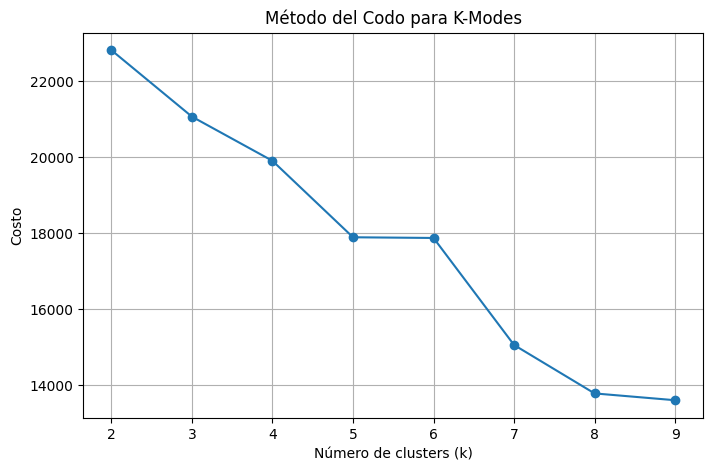

In [7]:
costs = []
ks = range(2, 10)

for k in ks:
    km = KModes(n_clusters=k, init='Cao', n_init=5, verbose=0)
    clusters = km.fit_predict(X)
    costs.append(km.cost_)

# Graficar la curva del codo, el “codo” es donde la curva deja de bajar bruscamente, ese será k óptimo
plt.figure(figsize=(8,5))
plt.plot(ks, costs, marker='o')
plt.title("Método del Codo para K-Modes")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Costo")
plt.grid(True)
plt.show()

## 3. Entrenar K‑Modes

In [8]:
k_opt = 5

km = KModes(n_clusters=k_opt, init='Cao', n_init=5, verbose=0)
clusters = km.fit_predict(X)

In [9]:
df_perfil["cluster"] = clusters
df_perfil["cluster"].value_counts().sort_index()

cluster
0    5546
1    1758
2    1212
3    1005
4    1466
Name: count, dtype: int64

In [10]:
df_perfil.head()

,job,marital,education,balance,housing,loan,deposit,age_group,cluster
0,administration,married,secondary,2343,yes,no,yes,56-65,0
1,administration,married,secondary,45,no,no,yes,56-65,0
2,technician,married,secondary,1270,yes,no,yes,36-45,0
3,services,married,secondary,2476,yes,no,yes,46-55,0
4,administration,married,tertiary,184,no,no,yes,46-55,2


## 3. Ver los centroides de cada cluster

In [11]:
centroides = km.cluster_centroids_
centroides

array([['26-35', 'management', 'married', 'secondary'],
       ['36-45', 'technician', 'single', 'tertiary'],
       ['46-55', 'technician', 'married', 'tertiary'],
       ['46-55', 'administration', 'single', 'secondary'],
       ['36-45', 'blue-collar', 'married', 'primary']], dtype='<U14')

## 4. Perfil de productos por cluster

In [12]:
balance_medio = df_perfil.groupby("cluster")["balance"].mean().round(2)

perfil_clusters = pd.DataFrame(km.cluster_centroids_, columns=cols_modelo)
perfil_clusters.index = [f"Cluster {i}" for i in range(perfil_clusters.shape[0])]
perfil_clusters["balance_medio"] = balance_medio.values

perfil_clusters

,age_group,job,marital,education,balance_medio
Cluster 0,26-35,management,married,secondary,1494.82
Cluster 1,36-45,technician,single,tertiary,1673.61
Cluster 2,46-55,technician,married,tertiary,1925.25
Cluster 3,46-55,administration,single,secondary,1196.86
Cluster 4,36-45,blue-collar,married,primary,1453.65


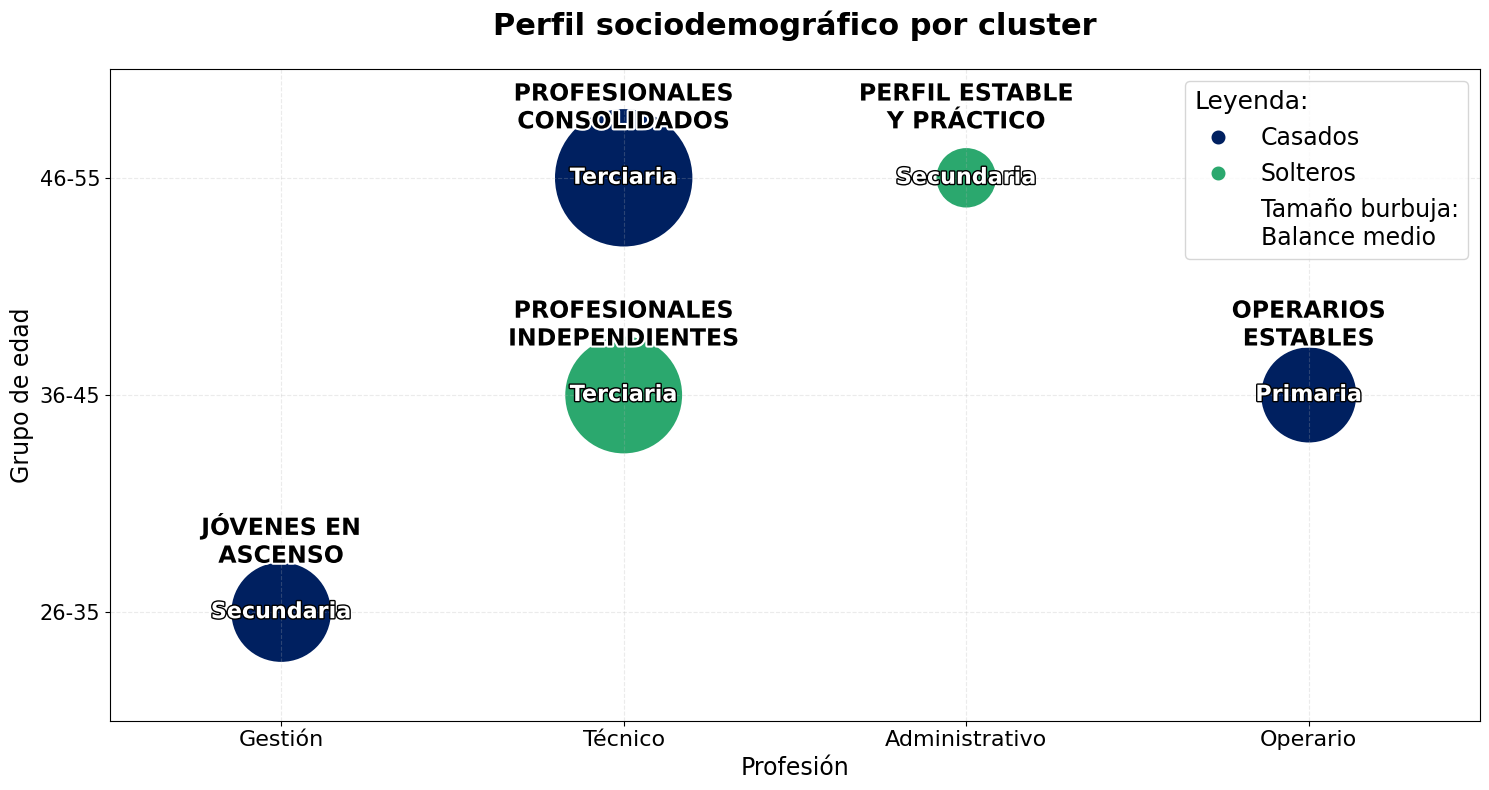

In [13]:
#CLUSTERS BALANCE MEDIO
# --- 1. Preparamos datos ---
df_plot = perfil_clusters.copy()
df_plot["cluster"] = df_plot.index

# Usar balance medio como tamaño de burbuja
df_plot["bubble_size"] = df_plot["balance_medio"]

# Nombres de clusters en mayúsculas y en dos líneas
nombres_clusters = [
    "JÓVENES EN\nASCENSO",
    "PROFESIONALES\nINDEPENDIENTES",
    "PROFESIONALES\nCONSOLIDADOS",
    "PERFIL ESTABLE\nY PRÁCTICO",
    "OPERARIOS\nESTABLES"
]
df_plot["cluster_name"] = nombres_clusters

# Traducción de educación
map_edu = {
    "primary": "Primaria",
    "secondary": "Secundaria",
    "tertiary": "Terciaria"
}
df_plot["education"] = df_plot["education"].map(map_edu)

# Traducción de profesión
map_job = {
    "management": "Gestión",
    "technician": "Técnico",
    "administration": "Administrativo",
    "blue-collar": "Operario"
}
df_plot["job"] = df_plot["job"].map(map_job)

# Traducción de estado civil
map_marital = {
    "married": "Casados",
    "single": "Solteros"
}
df_plot["marital"] = df_plot["marital"].map(map_marital)

# Asegurar strings
for col in ["age_group", "job", "education", "marital"]:
    df_plot[col] = df_plot[col].astype(str)

# --- 2. Colores por estado civil ---
palette = {"Solteros": "#2BA86E", "Casados": "#002060"}

plt.figure(figsize=(15, 8))

# --- 3. Bubble chart ---
ax = sns.scatterplot(
    data=df_plot,
    x="job",
    y="age_group",
    size="bubble_size",
    hue="marital",
    palette=palette,
    sizes=(1500, 9000),
    alpha=1,
    edgecolor=None
)

# --- 4. Texto dentro de la burbuja (educación) ---
for _, row in df_plot.iterrows():
    txt = plt.text(
        x=row["job"],
        y=row["age_group"],
        s=row["education"],
        ha="center",
        va="center",
        fontsize=16,
        color="white",
        fontweight="bold"
    )
    txt.set_path_effects([
        path_effects.Stroke(linewidth=2, foreground="black"),
        path_effects.Normal()
    ])

# --- 5. Texto fuera de la burbuja (nombre del cluster) ---
for _, row in df_plot.iterrows():
    txt = ax.annotate(
        row["cluster_name"],
        xy=(row["job"], row["age_group"]),
        xytext=(0, 32),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=17,
        fontweight="bold",
        color="black"
    )
    txt.set_path_effects([
        path_effects.Stroke(linewidth=3, foreground="white"),
        path_effects.Normal()
    ])

# --- 6. Títulos y estilo ---
plt.title("Perfil sociodemográfico por cluster", fontsize=22, fontweight="bold", pad=25)
plt.xlabel("Profesión", fontsize=17)
plt.ylabel("Grupo de edad", fontsize=17)

plt.xticks(rotation=0, ha="center", fontsize=16)
plt.yticks(fontsize=15)

plt.grid(axis="both", linestyle="--", alpha=0.25)

# --- 7. Ajustar límites para que no se corte nada ---
plt.ylim(-0.5, len(df_plot["age_group"].unique()) -0.5)
plt.xlim(-0.5, len(df_plot["job"].unique()) -0.5)

# --- 8. Leyenda unificada: Estado civil + Tamaño burbuja ---

handles, labels = ax.get_legend_handles_labels()
handles_estado = []
labels_estado = []

for h, l in zip(handles, labels):
    if l in ["Solteros", "Casados"]:
        handles_estado.append(h)
        labels_estado.append(l)

# Añadimos una línea de texto explicativa dentro de la misma leyenda

handle_tamano = Line2D([], [], color="none", label="Tamaño burbuja: Balance medio")

handles_final = handles_estado + [handle_tamano]
labels_final = labels_estado + ["Tamaño burbuja:\nBalance medio"]

legend = plt.legend(
    handles_final,
    labels_final,
    title="Leyenda:",
    loc="upper right",
    fontsize=17,
    title_fontsize=18,
    frameon=True
)

# Alinear título a la izquierda
legend.get_title().set_ha("left")
# Ajustar el ancho del cuadro para que el título no quede centrado visualmente
legend._legend_box.align = "left"

plt.tight_layout()
plt.show()

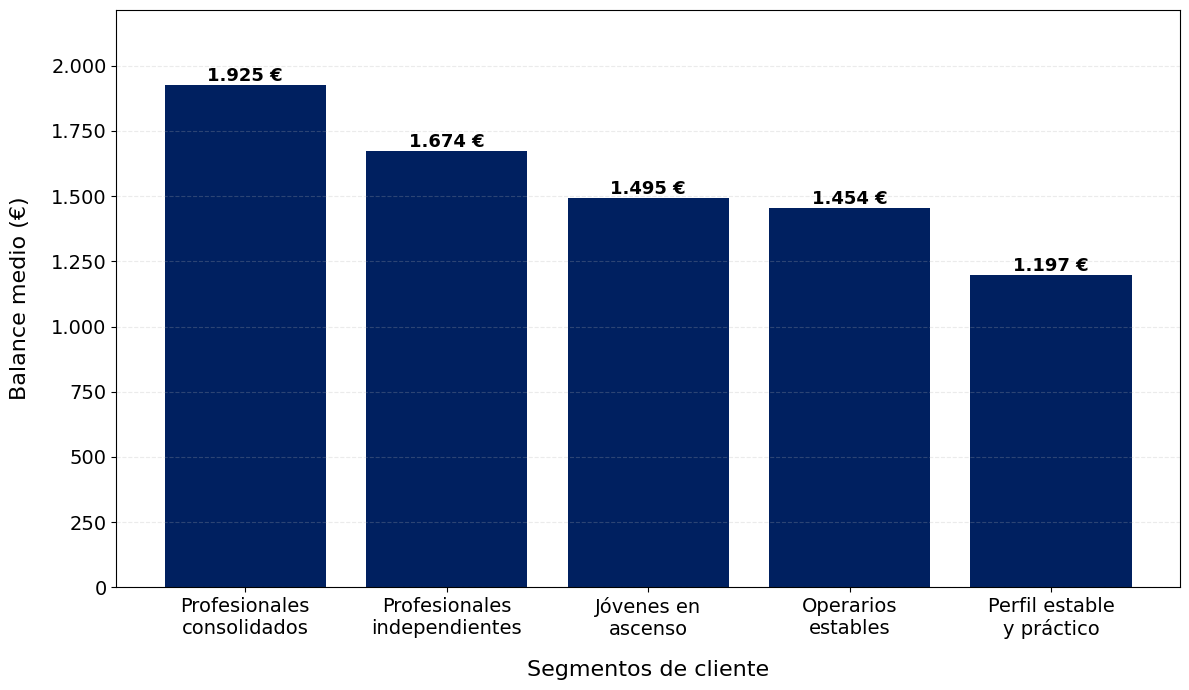

In [47]:
#S2 :Grafico balance medio por segmento
# --- 1. Nombres de los 5 segmentos ---
nombres_clusters = [
    "Jóvenes en\nascenso", 
    "Profesionales\nindependientes", 
    "Profesionales\nconsolidados", 
    "Perfil estable\ny práctico", 
    "Operarios\nestables"
]

# --- 2. Extraer balance medio ---
df_balance = perfil_clusters["balance_medio"].copy()
df_balance.index = nombres_clusters

# --- 3. Ordenar de mayor a menor ---
df_balance = df_balance.sort_values(ascending=False)

# --- 4. Gráfico ---
plt.figure(figsize=(12, 7))
bars = plt.bar(
    df_balance.index,
    df_balance.values,
    color="#002060"
)

# --- 5. Título y etiquetas ---
#plt.title("Balance medio por segmento de cliente", fontsize=18, fontweight="bold", pad=25)
plt.ylabel("Balance medio (€)", fontsize=16, labelpad=15)
plt.xlabel("Segmentos de cliente", fontsize=16, labelpad=15)

plt.xticks(rotation=0, fontsize=14)

# --- 6. Formato del eje Y con punto de miles ---
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", ".")))
plt.yticks(fontsize=14)

# --- 7. Etiquetas encima de cada barra con punto de miles ---
for bar in bars:
    height = bar.get_height()
    texto = f"{height:,.0f} €".replace(",", ".")   # ← punto de miles
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        texto,
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold"
    )

# --- 8. Ajuste de límites ---
plt.ylim(0, df_balance.max() * 1.15)

plt.grid(axis="y", linestyle="--", alpha=0.25)

plt.tight_layout()
plt.show()


## 5. Perfil demográfico por cluster

In [14]:
#Distribución de age_group:
cluster_age = pd.crosstab(df_perfil["cluster"], df_perfil["age_group"], normalize="index")
cluster_age

age_group,<=25,26-35,36-45,46-55,56-65,65+
cluster,,,,,,
0,0.006852,0.529030,0.227010,0.088172,0.118824,0.030112
1,0.098976,0.262799,0.556314,0.042662,0.031286,0.007964
2,0.004950,0.065182,0.000000,0.806106,0.082508,0.041254
3,0.215920,0.208955,0.151244,0.381095,0.039801,0.002985
4,0.006821,0.110505,0.490450,0.129604,0.150750,0.111869


In [15]:
#Distribución de job:
cluster_job = pd.crosstab(df_perfil["cluster"], df_perfil["job"], normalize="index")
cluster_job

job,administration,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,unknown
cluster,,,,,,,,,,,,
0,0.091237,0.129463,0.026145,0.016048,0.330148,0.062027,0.031374,0.118103,0.018211,0.137036,0.034800,0.005409
1,0.065984,0.051763,0.047213,0.017634,0.183732,0.024460,0.083618,0.055176,0.080774,0.333333,0.050057,0.006257
2,0.023927,0.024752,0.046205,0.054455,0.287954,0.103135,0.043729,0.037954,0.000825,0.344884,0.016502,0.015677
3,0.636816,0.077612,0.011940,0.012935,0.008955,0.013930,0.011940,0.065672,0.112438,0.019900,0.025871,0.001990
4,0.018417,0.673943,0.016371,0.046385,0.015689,0.166439,0.008186,0.028649,0.001364,0.006139,0.012960,0.005457


In [16]:
#Distribución de marital:
cluster_marital = pd.crosstab(df_perfil["cluster"], df_perfil["marital"], normalize="index")
cluster_marital

marital,divorced,married,single
cluster,,,
0,0.077894,0.672016,0.250090
1,0.134243,0.111490,0.754266
2,0.161716,0.838284,0.000000
3,0.207960,0.125373,0.666667
4,0.136426,0.802183,0.061392


In [17]:
#Distribución de education:
cluster_edu = pd.crosstab(df_perfil["cluster"], df_perfil["education"], normalize="index")
cluster_edu

education,primary,secondary,tertiary,unknown
cluster,,,,
0,0.019293,0.649297,0.292463,0.038947
1,0.032992,0.187144,0.719568,0.060296
2,0.131188,0.182343,0.614686,0.071782
3,0.024876,0.950249,0.005970,0.018905
4,0.763302,0.194407,0.002046,0.040246


In [18]:
#Propensión deposit:
cluster_deposit = pd.crosstab(df_perfil["cluster"], df_perfil["deposit"], normalize="index")
cluster_deposit

deposit,no,yes
cluster,,
0,0.526686,0.473314
1,0.432878,0.567122
2,0.535479,0.464521
3,0.462687,0.537313
4,0.615280,0.384720


In [19]:
#Propensión loan:
cluster_loan = pd.crosstab(df_perfil["cluster"], df_perfil["loan"], normalize="index")
cluster_loan

loan,no,yes
cluster,,
0,0.867292,0.132708
1,0.912969,0.087031
2,0.863861,0.136139
3,0.833831,0.166169
4,0.856753,0.143247


In [20]:
#Propensión housing:
cluster_housing = pd.crosstab(df_perfil["cluster"], df_perfil["housing"], normalize="index")
cluster_housing

housing,no,yes
cluster,,
0,0.512261,0.487739
1,0.582480,0.417520
2,0.638614,0.361386
3,0.528358,0.471642
4,0.432469,0.567531


In [21]:
#Resumen propensión productos:
propension_productos = (df_perfil.groupby("cluster")[["deposit", "loan", "housing"]].apply(lambda x: (x == "yes").mean()))

propension_productos

,deposit,loan,housing
cluster,,,
0,0.473314,0.132708,0.487739
1,0.567122,0.087031,0.417520
2,0.464521,0.136139,0.361386
3,0.537313,0.166169,0.471642
4,0.384720,0.143247,0.567531


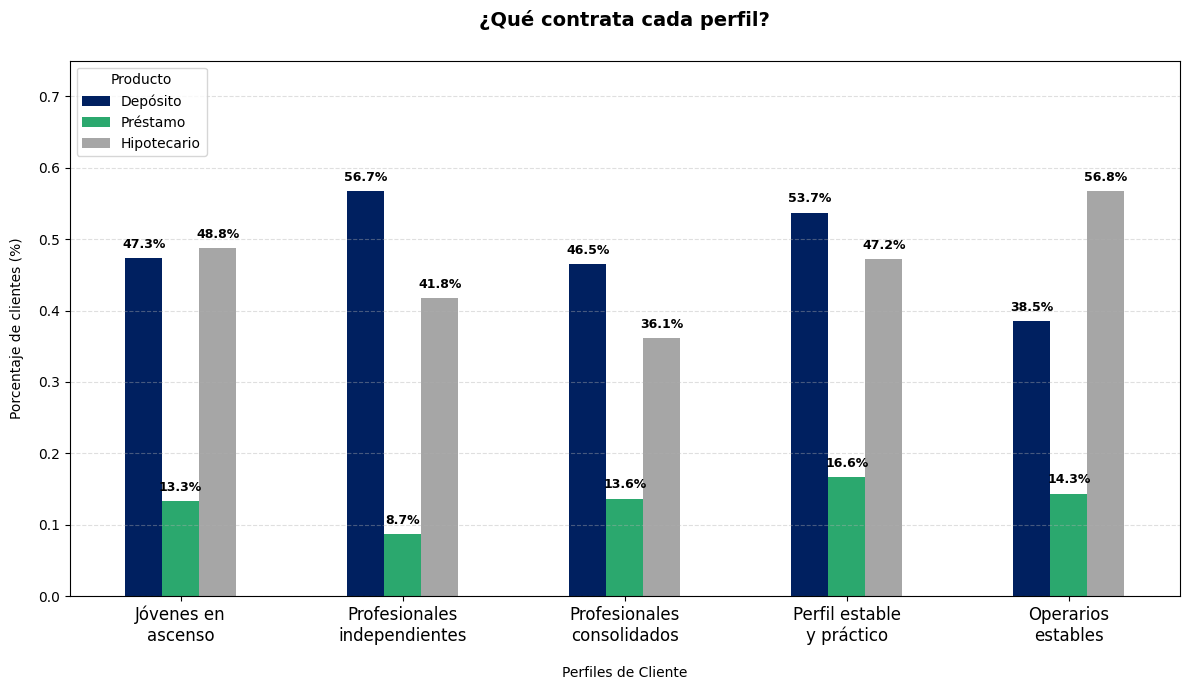

In [22]:
# 1. Nombres con salto de línea para que queden en dos filas
nombres_clusters = [
    "Jóvenes en\nascenso", 
    "Profesionales\nindependientes", 
    "Profesionales\nconsolidados", 
    "Perfil estable\ny práctico", 
    "Operarios\nestables"
]

# 2. Creamos el gráfico
ax = propension_productos.plot(kind='bar', figsize=(12, 7), color=['#002060', "#2BA86E", '#A6A6A6'])

# 3. Títulos y etiquetas
plt.title("¿Qué contrata cada perfil?", fontsize=14, fontweight='bold', pad=25)
plt.ylabel("Porcentaje de clientes (%)", labelpad=10)
plt.xlabel("Perfiles de Cliente", labelpad=15)

# Ajuste de nombres en el eje X
plt.xticks(range(len(nombres_clusters)), nombres_clusters, rotation=0, fontsize=12)

# --- CAMBIO CLAVE: UBICACIÓN DE LA LEYENDA ---
# 'upper left' la mueve a la izquierda, y aumentamos el límite de Y para dar espacio
plt.legend(title="Producto", labels=['Depósito', 'Préstamo', 'Hipotecario'], loc='upper left')
plt.ylim(0, 0.75) # Aumentamos el tope al 75% para que la leyenda no tape las barras
# ---------------------------------------------

plt.grid(axis='y', linestyle='--', alpha=0.4)

# 4. Etiquetas de porcentaje sobre las barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points', 
                fontsize=9, 
                fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Indicador para valorar para poder comparar clusters:
Índice de propensión

In [23]:
#Probabilidad global:
p_global = {"deposit": (df_perfil["deposit"] == "yes").mean(),
            "loan": (df_perfil["loan"] == "yes").mean(),
            "housing": (df_perfil["housing"] == "yes").mean()}

#Probabilidad por cluster:
p_cluster = df_perfil.groupby("cluster")[["deposit", "loan", "housing"]].apply(lambda x: (x == "yes").mean())

#Índice de propensión:
indice_propension = pd.DataFrame({"deposit_index": p_cluster["deposit"] / p_global["deposit"],
                                  "loan_index": p_cluster["loan"] / p_global["loan"],
                                  "housing_index": p_cluster["housing"] / p_global["housing"]})

indice_propension

,deposit_index,loan_index,housing_index
cluster,,,
0,0.983230,1.018914,1.033916
1,1.178099,0.668209,0.885065
2,0.964964,1.045252,0.766072
3,1.116177,1.275821,0.999793
4,0.799191,1.099828,1.203060


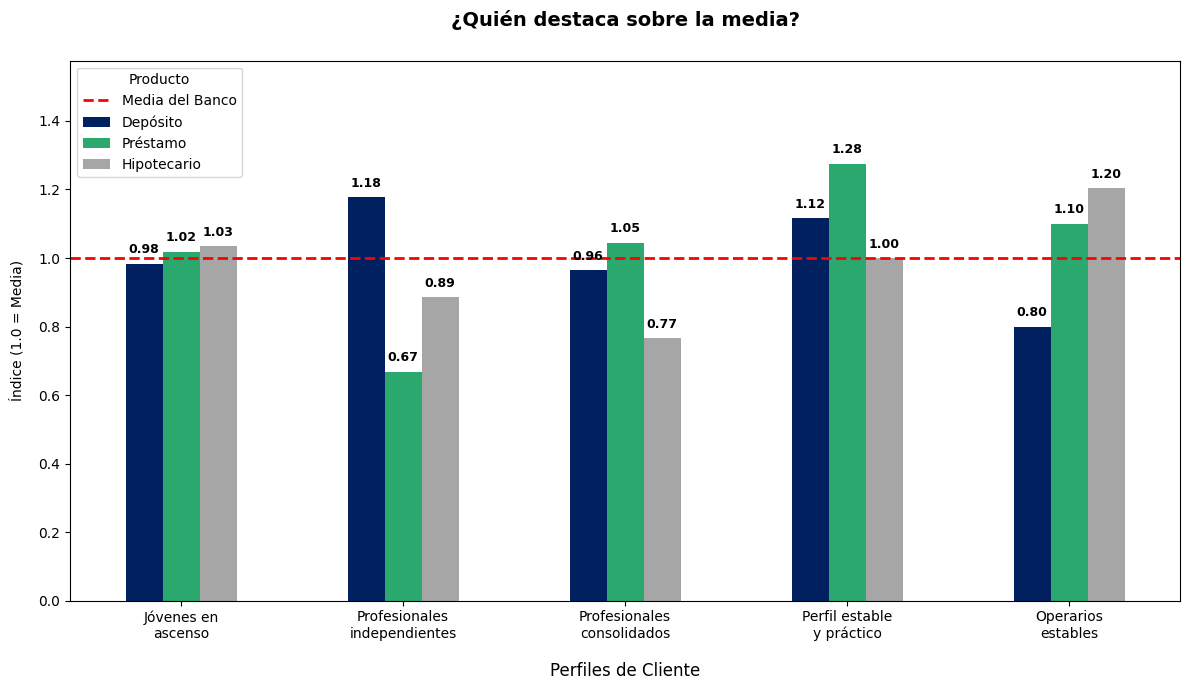

In [24]:
#Nombres con salto de línea para legibilidad
nombres_clusters = [
    "Jóvenes en\nascenso", 
    "Profesionales\nindependientes", 
    "Profesionales\nconsolidados", 
    "Perfil estable\ny práctico", 
    "Operarios\nestables"
]

#columnas  castellano
indice_es = indice_propension.rename(columns={
    "deposit_index": "Depósito",
    "loan_index": "Préstamo",
    "housing_index": "Hipotecario"
})
ax = indice_es.plot(kind='bar', figsize=(12, 7), color=['#002060', "#2BA86E", '#A6A6A6'])

#Título y Etiquetas
plt.title("¿Quién destaca sobre la media?", fontsize=14, fontweight='bold', pad=25)
plt.ylabel("Índice (1.0 = Media)", labelpad=10)
plt.xlabel("Perfiles de Cliente", fontsize=12, labelpad=15) # 

plt.xticks(range(len(nombres_clusters)), nombres_clusters, rotation=0, fontsize=10)

#Línea de referencia 
plt.axhline(y=1, color='red', linestyle='--', linewidth=2, label="Media del Banco")

#Leyenda
plt.legend(title="Producto", loc='upper left')
plt.ylim(0, max(indice_es.max()) + 0.3) # Espacio para que no tape nada

#Etiquetas de valor sobre las barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points', 
                fontsize=9, 
                fontweight='bold')

plt.tight_layout()
plt.show()

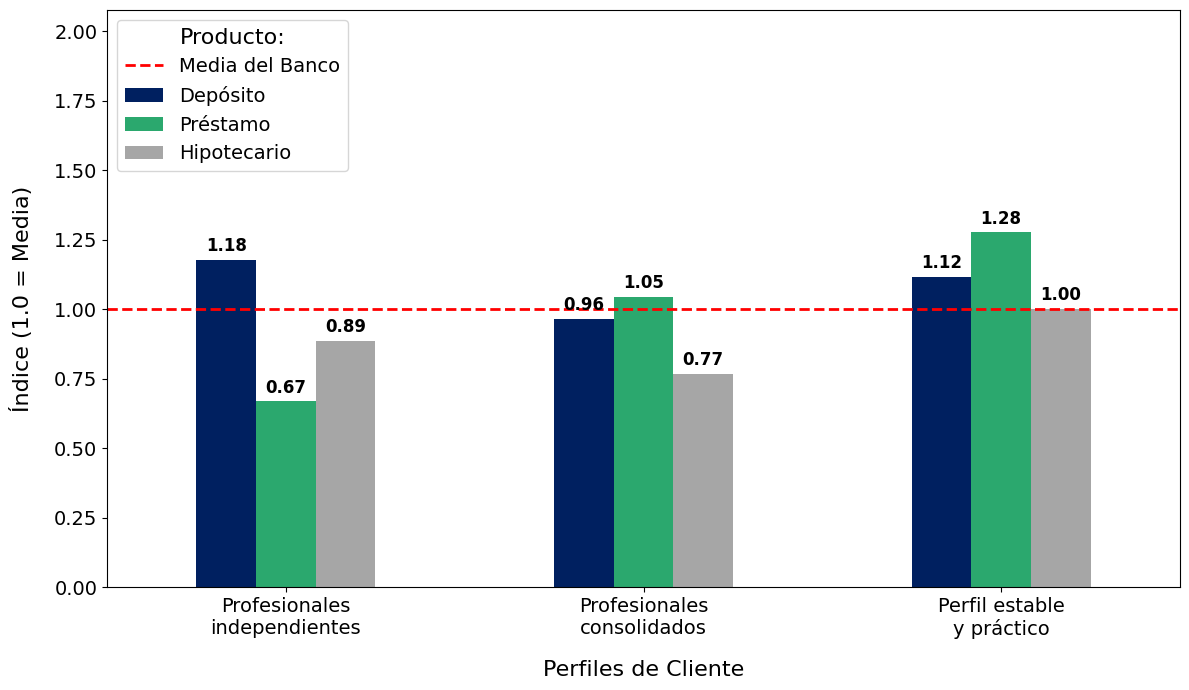

In [48]:
#S2: para clústers 1, 2 y 3:
# --- 1. Nombres con salto de línea para legibilidad ---
nombres_clusters = [
    "Profesionales\nindependientes", 
    "Profesionales\nconsolidados", 
    "Perfil estable\ny práctico"
]

# --- 2. Filtrar solo clusters 1, 2 y 3 ---
clusters_seleccionados = [1, 2, 3]
indice_filtrado = indice_propension.loc[clusters_seleccionados]

# --- 3. Columnas en castellano ---
indice_es = indice_filtrado.rename(columns={
    "deposit_index": "Depósito",
    "loan_index": "Préstamo",
    "housing_index": "Hipotecario"
})

# --- 4. Gráfico ---
ax = indice_es.plot(
    kind='bar',
    figsize=(12, 7),
    color=['#002060', "#2BA86E", '#A6A6A6']
)

# --- 5. Título y etiquetas ---
#plt.title("¿Quién destaca sobre la media?", fontsize=18, fontweight='bold', pad=25)
plt.ylabel("Índice (1.0 = Media)", fontsize=16, labelpad=15)
plt.xlabel("Perfiles de Cliente", fontsize=16, labelpad=15)
plt.yticks(fontsize=14)
plt.xticks(
    ticks=range(len(nombres_clusters)),
    labels=nombres_clusters,
    rotation=0,
    fontsize=14
)

# --- 6. Línea de referencia ---
plt.axhline(y=1, color='red', linestyle='--', linewidth=2, label="Media del Banco")

# --- 7. Leyenda ---
plt.legend(
    title="Producto:",
    loc='upper left',
    fontsize=14,
    title_fontsize=16
)

# --- 8. Ajuste de límites ---
plt.ylim(0, max(indice_es.max()) + 0.8)

# --- 9. Etiquetas de valor sobre las barras ---
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.2f}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 10),
        textcoords='offset points',
        fontsize=12,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

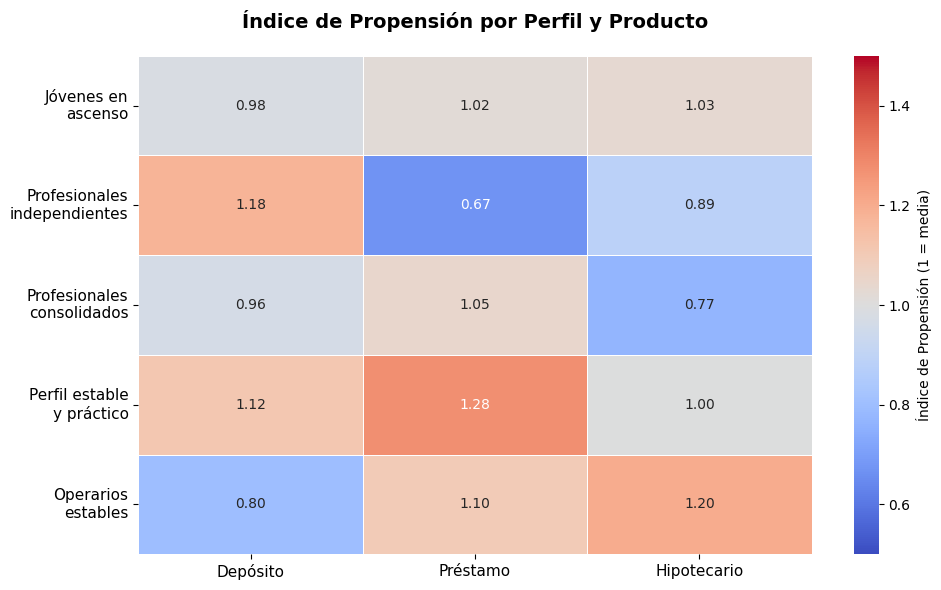

In [26]:
#Heatmap índice de propensión:
#Renombrar columnas a castellano
indice_es = indice_propension.rename(columns={
    "deposit_index": "Depósito",
    "loan_index": "Préstamo",
    "housing_index": "Hipotecario"
})

#Añadir nombres de perfiles
indice_es.index = [
    "Jóvenes en\nascenso", 
    "Profesionales\nindependientes", 
    "Profesionales\nconsolidados", 
    "Perfil estable\ny práctico", 
    "Operarios\nestables"
]

#Heatmap
plt.figure(figsize=(10, 6))
ax = sns.heatmap(
    indice_es,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=0.5,
    vmax=1.5,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Índice de Propensión (1 = media)"}
)

#Título
plt.title("Índice de Propensión por Perfil y Producto", fontsize=14, fontweight="bold", pad=20)

#Ajustes de ejes
plt.xticks(rotation=0, fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

## 7. Análisis por perfil incluyendo balance

In [27]:
perfil_financiero = indice_propension.copy()
perfil_financiero["balance_medio"] = balance_medio

perfil_financiero = perfil_financiero.round(2)
perfil_financiero.index = [
    "Jóvenes en ascenso",
    "Profesionales independientes",
    "Profesionales consolidados",
    "Perfil estable y práctico",
    "Operarios estables"
]

perfil_financiero

,deposit_index,loan_index,housing_index,balance_medio
Jóvenes en ascenso,0.98,1.02,1.03,1494.82
Profesionales independientes,1.18,0.67,0.89,1673.61
Profesionales consolidados,0.96,1.05,0.77,1925.25
Perfil estable y práctico,1.12,1.28,1.00,1196.86
Operarios estables,0.80,1.10,1.20,1453.65


### ANOVA 

Análisis de rentabilidad (sobre el balance)

In [28]:
#Crear listas de balance por cluster
grupos_balance = [df_perfil[df_perfil["cluster"] == c]["balance"] 
                  for c in df_perfil["cluster"].unique()]

#ANOVA
anova_balance = f_oneway(*grupos_balance)
anova_balance

F_onewayResult(statistic=np.float64(8.400816229487985), pvalue=np.float64(9.19374135838496e-07))

F = 8.40 y p-value = 0.000000919, indica que las diferencias de balance entre clusters son estadísticamente significativas. Implica que el balance sí depende del cluster y los segmentos tienen comportamientos financieros distintos.

### Post-hoc (Prueba deTukey)

¿Dónde está la diferencia en el Balance?

In [29]:
#Prueba post‑hoc Tukey HSD para ver diferencias entre clusters:
tukey = pairwise_tukeyhsd(
    endog=df_perfil["balance"],
    groups=df_perfil["cluster"],
    alpha=0.05
)

print(tukey)

   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
group1 group2  meandiff p-adj    lower      upper   reject
----------------------------------------------------------
     0      1  178.7873 0.2569   -62.8274   420.402  False
     0      2  430.4222 0.0003   150.5175  710.3269   True
     0      3  -297.962 0.0561  -600.5998    4.6758  False
     0      4  -41.1743 0.9927  -300.4169  218.0683  False
     1      2   251.635 0.2274   -77.9443  581.2142  False
     1      3 -476.7492 0.0018  -825.8416 -127.6569   True
     1      4 -219.9615 0.3055  -532.1835   92.2604  False
     2      3 -728.3842    0.0 -1104.9933  -351.775   True
     2      4 -471.5965 0.0016  -814.3085 -128.8845   True
     3      4  256.7877 0.2972  -104.7293  618.3047  False
----------------------------------------------------------


Interpretación balance:
Cluster 2 (Profesionales consolidados):
→ Tiene el balance más alto  
→ Es significativamente mayor que:
Cluster 0 (Jóvenes en ascenso), Cluster 3 (Perfil estable y práctico) y Cluster 4 (Operarios estables).

Cluster 3 (Perfil estable y práctico)
→ Tiene uno de los balances más bajos  
→ Es significativamente menor que:
Cluster 1 (Profesionales independientes) y Cluster 2 (Profesionales consolidados)

Cluster 1 (Profesionales independientes)
→ Tiene balance medio-alto
→ Es significativamente mayor que Cluster 3

### Chi‑cuadrado

In [30]:
tabla_deposit = pd.crosstab(df_perfil["cluster"], df_perfil["deposit"])
chi2_deposit = stats.chi2_contingency(tabla_deposit)

tabla_loan = pd.crosstab(df_perfil["cluster"], df_perfil["loan"])
chi2_loan = stats.chi2_contingency(tabla_loan)

tabla_housing = pd.crosstab(df_perfil["cluster"], df_perfil["housing"])
chi2_housing = stats.chi2_contingency(tabla_housing)

print(f"p-value para deposit: {chi2_deposit[1]}")
print(f"p-value para loan: {chi2_loan[1]}")
print(f"p-value para housing: {chi2_housing[1]}")

p-value para deposit: 1.9471044517137691e-25
p-value para loan: 9.021951905359837e-09
p-value para housing: 3.3651265150538137e-29


Conclusión general:
La contratación de depósitos, préstamos y viviendas depende significativamente del cluster.
Los clusters realmente tienen comportamientos financieros distintos.

## Gap Aanalysis

análisis de brechas basado en el balance


In [31]:
# métricas por cluster
# deposit de binario a 1/0
df_perfil['deposit_binary'] = df_perfil['deposit'].map({'yes': 1, 'no': 0})

gap_analysis = df_perfil.groupby('cluster').agg({
    'balance': 'mean',
    'deposit_binary': 'mean'
}).rename(columns={'deposit_binary': 'conversion_rate'})

# métrica de "Potencial" (normalizando el balance para poder comprar)
# Esto nos dice qué tan valioso es el cluster del 0 al 1
gap_analysis['potential_score'] = (gap_analysis['balance'] - gap_analysis['balance'].min()) / (gap_analysis['balance'].max() - gap_analysis['balance'].min())

# aqui se calcula el gap
# Un Gap alto significa: "Tienen mucho dinero (potencial) pero convierten poco"
gap_analysis['gap'] = gap_analysis['potential_score'] - gap_analysis['conversion_rate']

print("--- TABLA DE GAP ANALYSIS ---")
print(gap_analysis.sort_values(by='gap', ascending=False))


--- TABLA DE GAP ANALYSIS ---
             balance  conversion_rate  potential_score       gap
cluster                                                         
2        1925.245875         0.464521         1.000000  0.535479
1        1673.610922         0.567122         0.654530  0.087408
4        1453.649386         0.384720         0.352544 -0.032176
0        1494.823657         0.473314         0.409073 -0.064242
3        1196.861692         0.537313         0.000000 -0.537313


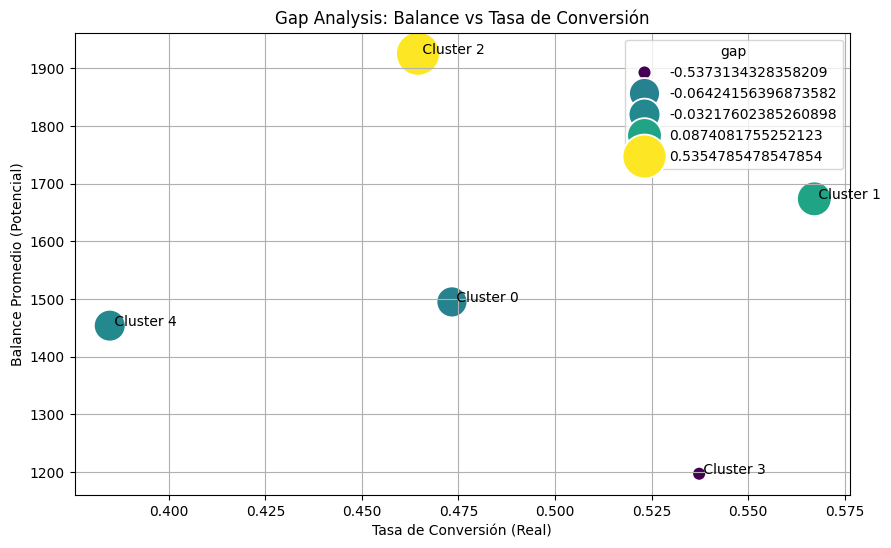

In [32]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=gap_analysis, x='conversion_rate', y='balance', size='gap', hue='gap', sizes=(100, 1000), palette='viridis')

for i in range(gap_analysis.shape[0]):
    plt.text(gap_analysis.conversion_rate[i], gap_analysis.balance[i], f" Cluster {gap_analysis.index[i]}")

plt.title('Gap Analysis: Balance vs Tasa de Conversión')
plt.xlabel('Tasa de Conversión (Real)')
plt.ylabel('Balance Promedio (Potencial)')
plt.grid(True)
plt.show()

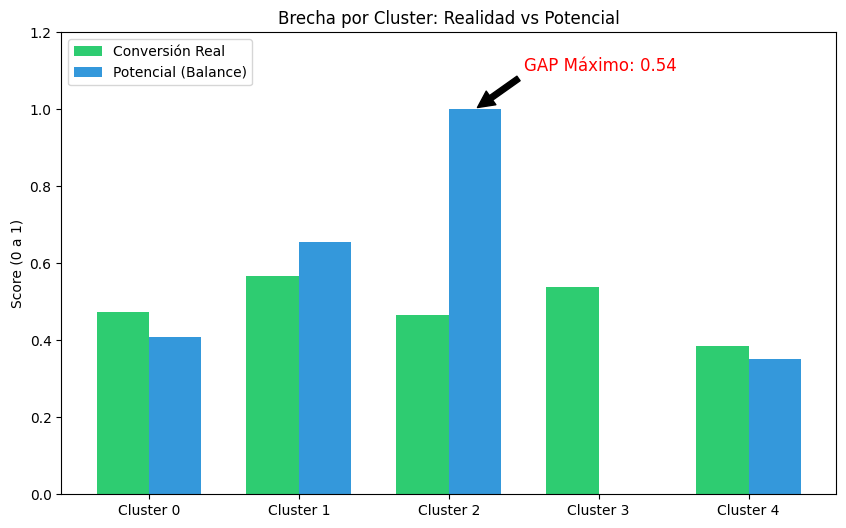

In [33]:
labels = gap_analysis.index
conversion = gap_analysis['conversion_rate']
potencial = gap_analysis['potential_score']

x = np.arange(len(labels))  # Localización de las etiquetas
width = 0.35  # Ancho de las barras

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, conversion, width, label='Conversión Real', color='#2ecc71')
rects2 = ax.bar(x + width/2, potencial, width, label='Potencial (Balance)', color='#3498db')

# Añadir etiquetas y títulos
ax.set_ylabel('Score (0 a 1)')
ax.set_title('Brecha por Cluster: Realidad vs Potencial')
ax.set_xticks(x)
ax.set_xticklabels([f'Cluster {i}' for i in labels])
ax.legend()

# Añadir una flecha o anotación en el Cluster 2 que es el del GAP más grande
gap_c2 = potencial[2] - conversion[2]
ax.annotate(f'GAP Máximo: {gap_c2:.2f}', xy=(2 + width/2, potencial[2]), xytext=(2.5, potencial[2]+0.1),
            arrowprops=dict(facecolor='black', shrink=0.05), fontsize=12, color='red')

plt.ylim(0, 1.2) # Espacio para la leyenda
plt.show()

 Clusters con Gap Positivo (Alto Balance, Baja Conversión) --> segmentos que tienen dinero pero no les estamos llegando bien
    - Requieren un cambio de mensaje o de canal
- Clusters con Gap Negativo (Bajo Balance, Alta Conversión) --> segmentos muy fieles pero con poco capital
    - No gaster mucho esfuerzo en llamadas largas; automatización (apps, plataformaas, facil contratacion)

Conclusiones:

- cluster 2:
    - es el que mayor balance tiene pero una tasa de conversion del 46%, tiene es el que mayor gap positivo tiene
    tiene mucha plata pero contrata poco
    - Se les debe ofrecer productos de inversión de alto valor o depósitos a plazo con tasas preferenciales. Al tener saldos altos, son menos sensibles a promociones pequeñas y más sensibles a la rentabilidad y exclusividad.
- cluster 1:
    - Es el que mejor tasa de conversion tiene56.7% pero tambien tiene balance solido
    - Es buen cliente, nos interesa mantenerlo --> fidelizaciones
- cluster 4:
    - Es el de menor tasa de conversion 38.47% con un balance intermedio
    - re-estructuracion-->ofrecerles otros productos o llegarles por otro canal
- cluster 0: 
    - tasa de conversion de 47.33% con balance intermedio 
    - su gap es muy cercano a cero
- cluster 3: 
    - es el que menos balance tiene pero aun asi tiene la segunda mejor tasa de conversion 53%
    - Tambienn es el que mas gap negativo tiene, es decir, contratan mucho para el poco capital que tienen
    - Son clientes muy leales pero de baja rentabilidad individual.
    - Automatización y bajo costo

## 7. Conclusiones

Los cinco segmentos muestran comportamientos financieros claramente diferenciados, tanto en balance como en contratación de productos, y estas diferencias son estadísticamente significativas.

Profesionales consolidados es el segmento más rentable, con el balance más alto y potencial para productos de inversión y servicios premium.

Perfil estable y práctico y Operarios estables destacan por su alta propensión a financiación, siendo claves para préstamos personales e hipotecas, respectivamente.

Profesionales independientes presenta una alta orientación al ahorro, ideal para depósitos e inversión.

Jóvenes en ascenso mantiene un comportamiento neutro, adecuado para estrategias de entrada y fidelización.

1. Jóvenes en ascenso (Cluster 0)

Balance medio: medio
Propensión: todo en niveles medios (depósitos, préstamos y vivienda)
No destacan ni por arriba ni por abajo
Insight clave: segmento neutro; buen target para productos de entrada y fidelización temprana.

2. Profesionales independientes (Cluster 1)

Balance medio: medio‑alto
Propensión:
Depósitos: alta
Préstamos: baja
Vivienda: baja‑media
Insight clave: perfil ahorrador; ideal para productos de inversión y ahorro. Poco receptivo a financiación.

3. Profesionales consolidados (Cluster 2)

Balance medio: el más alto del banco
Propensión:
Depósitos: baja‑media
Préstamos: media‑alta
Vivienda: baja
Insight clave: segmento más rentable; foco en productos premium, inversión y gestión patrimonial.

4. Perfil estable y práctico (Cluster 3)

Balance medio: el más bajo
Propensión:
Depósitos: alta
Préstamos: muy alta
Vivienda: media
Insight clave: segmento muy activo en financiación; oportunidad en préstamos personales y seguros asociados.

5. Operarios estables (Cluster 4)

Balance medio: medio
Propensión:
Depósitos: baja
Préstamos: alta
Vivienda: muy alta
Insight clave: segmento clave para hipotecas y productos vinculados a vivienda.